| Name                        | Questions        | Contribution                                                                 |
|-----------------------------|------------------|------------------------------------------------------------------------------|
| Jisna D Kunju               |                  |                                                                              |
| Jissy Jayaprakash           |                  |                                                                              |
| Anjitha Mohan               |      |    |
| Aman Nain                   |                  |                                                                              |
| Prakash Phakami Pun         |                  |                                                                              |
| Bibek Ranjit                |                  |                                                                              |
| Leandro Sartini de Campos   |   |                                 |
| Jorge Rodrigo Velazquez     |  |                                         |


For the group assignment, build the following generative models to generate images using the Yelp dataset.

1. a DCGAN

2. a WGAN

3. a VAE (variational autoencoder)

4. a cGAN (to generate the images as per the label [food, drink, inside, outside])

Evaluate the models using Inception Score and Frechet Inception Distance using a pretrained model

Submit 5 generated images (atleast one for each label in the cGAN) using each model

At the top of your ipynb files, share the 5 generated images using each model and the IS and FID metrics for each model. Clear and specific responses are expected.

Submit your ipynb file run end-to-end sequentially, and convert it to pdf.



Prompt Used:



# Imports

In [1]:
import json
import os
import warnings
warnings.filterwarnings("ignore")
#!pip install opencv-python
#!pip install matplotlib
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelBinarizer

import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# Optionally suppress other verbose logs
tf.get_logger().setLevel('ERROR')
from tensorflow.keras.models import Model

2025-03-21 20:35:30.194321: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-21 20:35:30.208716: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742603730.225483    4179 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742603730.233072    4179 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1742603730.245097    4179 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

# Data Exploration

In [2]:
data = []
json_path = '../Dataset/photos.json'

with open(json_path, 'r') as file:
    for line in file:
        data.append(json.loads(line.strip()))

In [3]:
len(data)

200100

In [4]:
data[0]

{'photo_id': 'zsvj7vloL4L5jhYyPIuVwg',
 'business_id': 'Nk-SJhPlDBkAZvfsADtccA',
 'caption': 'Nice rock artwork everywhere and craploads of taps.',
 'label': 'inside'}

In [5]:
#Lets extract the photo ID from the json file
photo_ids_json = [entry['photo_id'] for entry in data]

In [6]:
# Check the photos folder
photos_folder = '../Dataset/photos'
photo_files = os.listdir(photos_folder)
photo_ids_folder = [os.path.splitext(file)[0] for file in photo_files]

In [7]:
missing_photos = set(photo_ids_json) - set(photo_ids_folder)
extra_photos = set(photo_ids_folder) - set(photo_ids_json)


In [8]:
missing_photos

set()

In [9]:
extra_photos

set()

We can see there are no extra or missing photos between the json file and the photos folder

BGR (Blue-Green-Red): This is the default color format used by OpenCV when it reads an image. The pixel values are stored in the order of blue, green, and red channels.
RGB (Red-Green-Blue): This is the standard color format used for displaying images in most visualization tools, including matplotlib.

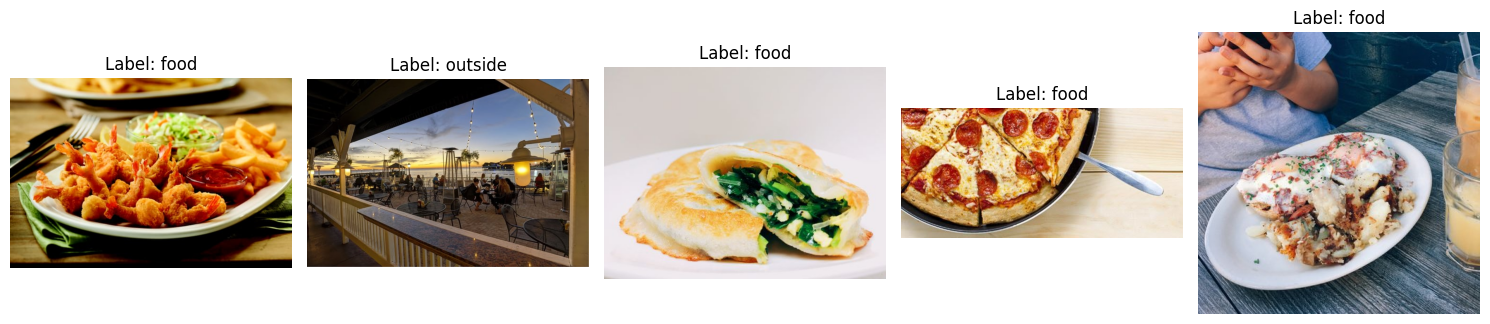

In [10]:
def show_sample_images(data, photos_folder, num_samples=5):
    # Randomly select samples from the dataset
    samples = random.sample(data, num_samples)

    # Create a plot
    plt.figure(figsize=(15, 10))

    for i, entry in enumerate(samples):
        photo_id = entry['photo_id']
        label = entry['label']
        img_path = os.path.join(photos_folder, photo_id + '.jpg')

        # Load the image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for visualization

        # Display the image with its label
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"Label: {label}", fontsize=12)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to display images
show_sample_images(data, photos_folder, num_samples=5)


In this sample we can see 5 images and the label associated, so we can give us an idea of the type of images and clases present in the dataset

In [11]:
classes=[]
for i,entry in enumerate(data):
    label = entry['label']
    classes.append(label)

set(classes)

{'drink', 'food', 'inside', 'menu', 'outside'}

We can see the dataset contains 5 different classes: 'drink', 'food', 'inside', 'menu', 'outside'

Check for data imbalance

In [12]:
df = pd.DataFrame(data)
label_counts = df['label'].value_counts()
label_counts


label
food       108152
inside      56031
outside     18569
drink       15670
menu         1678
Name: count, dtype: int64

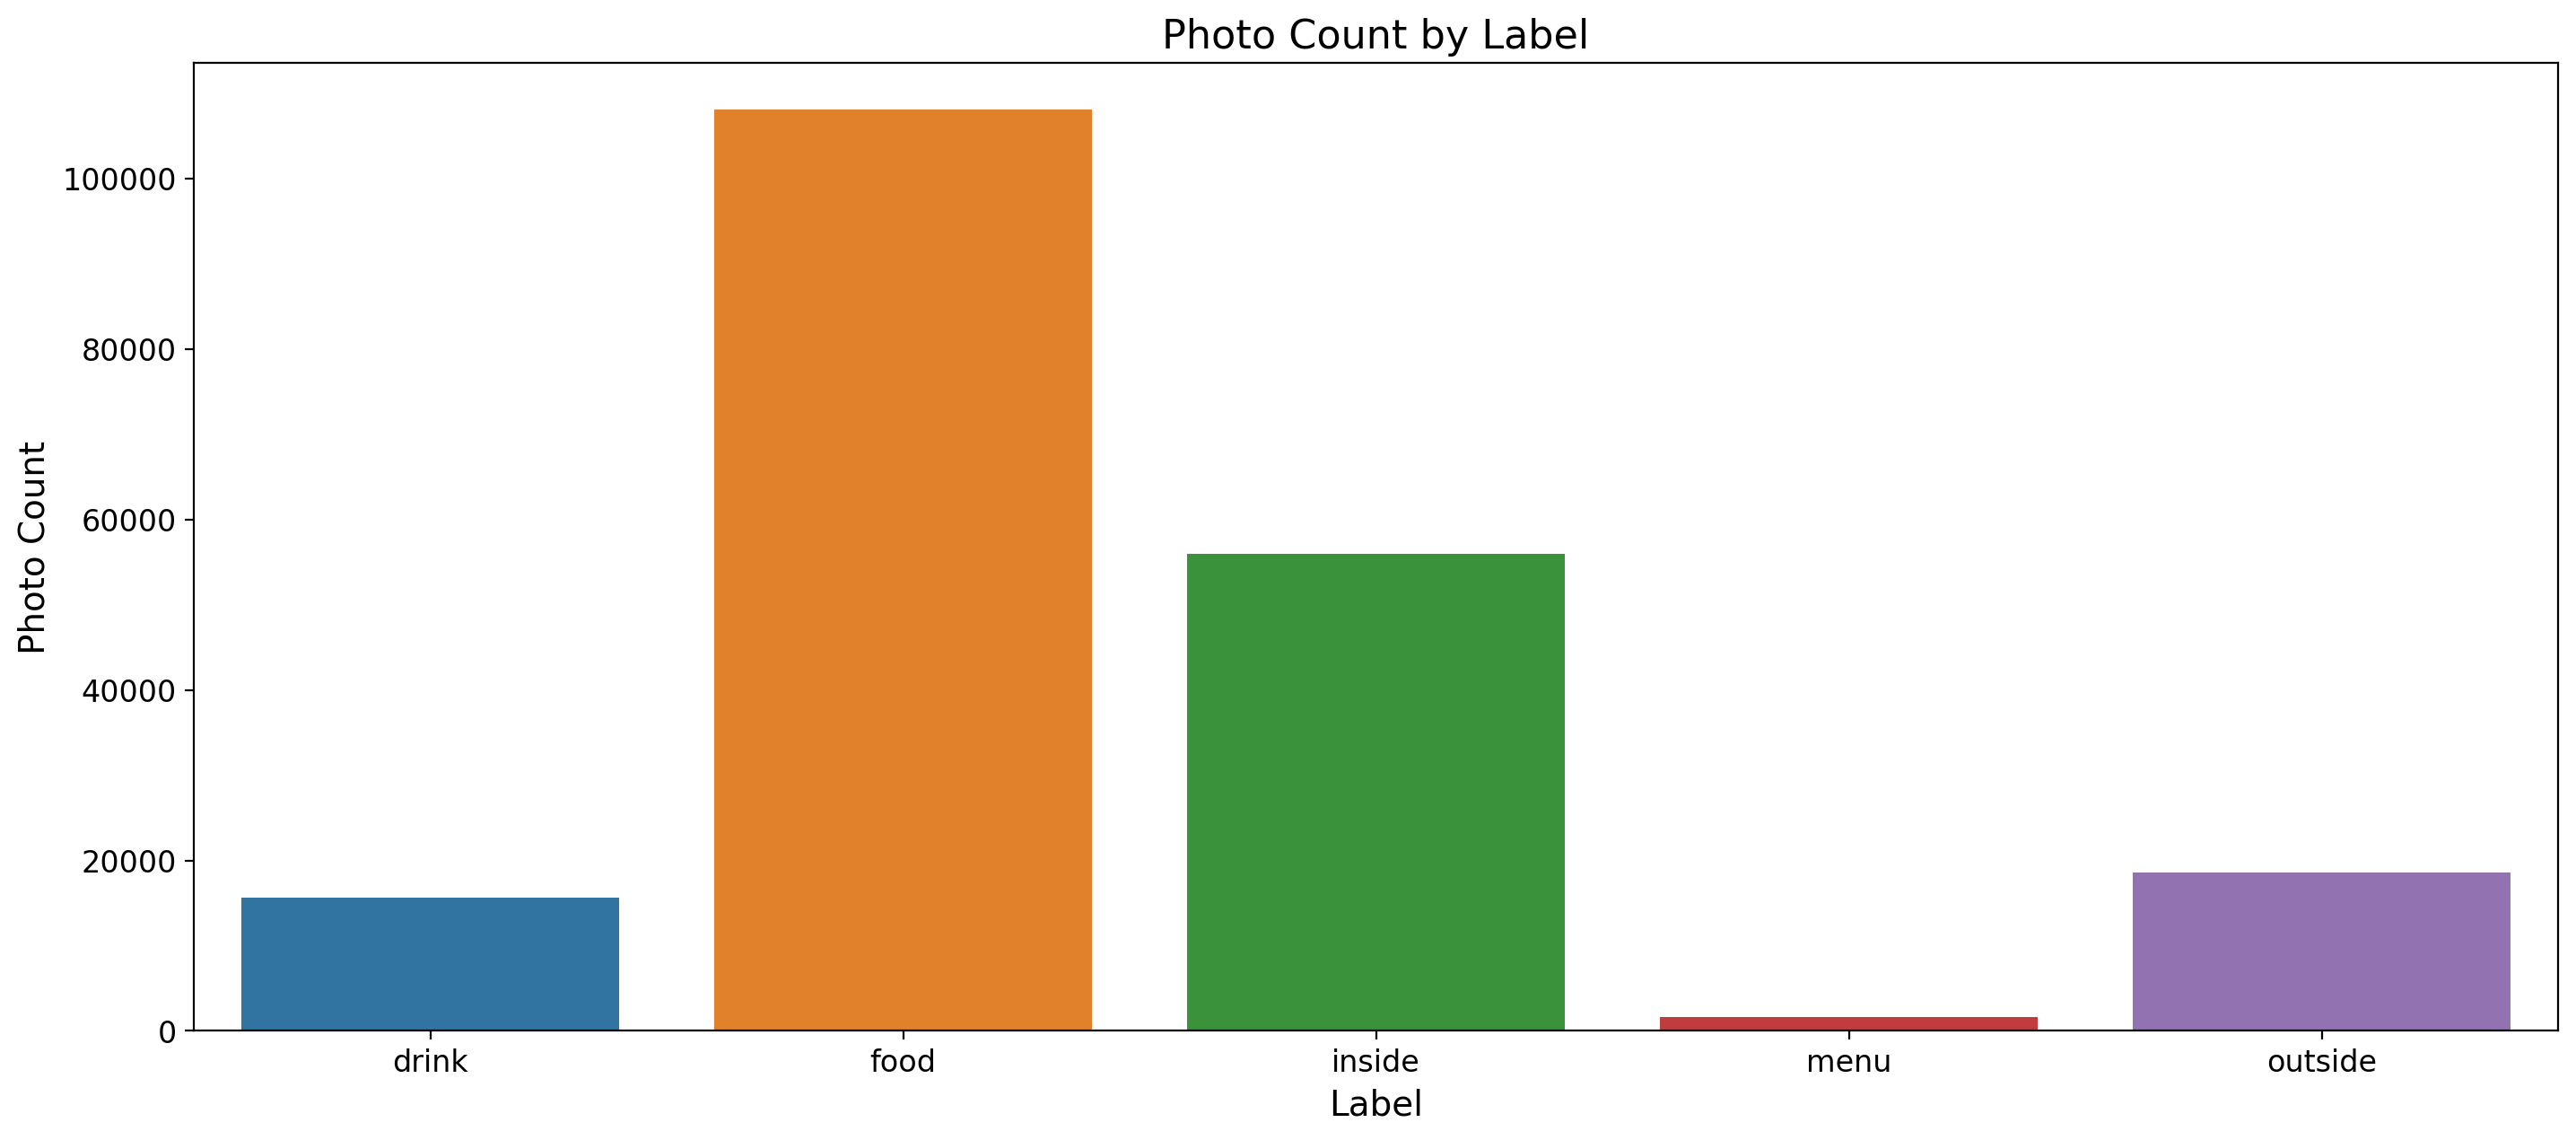

In [13]:
plt.figure(figsize=[17, 7],dpi=200)
sns.barplot(data=df.groupby('label')['photo_id'].count().to_frame().reset_index(),x='label', hue='label', y='photo_id')
plt.title("Photo Count by Label", fontsize=16)
plt.xlabel("Label", fontsize=14)
plt.ylabel("Photo Count", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

We can appreciate the menu class is being underrepresented, so before training we will perform data augmentation. 

# Functions

In [5]:
import tensorflow as tf

# List available GPUs
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # Set memory growth for each GPU
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth set for GPUs.")
    except RuntimeError as e:
        print(f"Error setting memory growth: {e}")
else:
    print("No GPU found.")


Memory growth set for GPUs.


In [58]:
photos_df = pd.read_json(json_path, lines=True)

In [61]:
photos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200100 entries, 0 to 200099
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   photo_id     200100 non-null  object
 1   business_id  200100 non-null  object
 2   caption      200100 non-null  object
 3   label        200100 non-null  object
dtypes: object(4)
memory usage: 6.1+ MB


In [63]:
# Ensure TensorFlow uses GPU
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Prevent full memory allocation
        tf.config.set_visible_devices(gpus[0], 'GPU')
        print("✅ GPU is now being used for TensorFlow!")
    except RuntimeError as e:
        print(e)

✅ GPU is now being used for TensorFlow!


### Filter Valid Images using GPU and TF

In [2]:
# def filter_valid_images(photo_ids, img_dir):
# #    """Check for missing/corrupt images and return a cleaned DataFrame."""
#     valid_photo_ids = []
#     invalid_photo_ids = []
# #
#     for photo_id in photo_ids:
#         img_path = os.path.join(img_dir, f"{photo_id}.jpg")
#         if os.path.exists(img_path):
#             try:
#                 img = tf.io.read_file(img_path)
#                 img = tf.image.decode_jpeg(img, channels=3)  # Try decoding to detect corruption
#                 valid_photo_ids.append(photo_id)
#             except tf.errors.InvalidArgumentError:
#                 invalid_photo_ids.append(photo_id)

#     print(f"✅ {len(valid_photo_ids)} valid images, ❌ {len(invalid_photo_ids)} corrupt images removed.")
#     return valid_photo_ids

# # Filter the dataset and update the DataFrame
# valid_photo_ids = filter_valid_images(photos_df["photo_id"], "Dataset/photos")
# cleaned_photos_df = photos_df[photos_df["photo_id"].isin(valid_photo_ids)].reset_index(drop=True)

# ## Save cleaned DataFrame
# cleaned_photos_df.to_csv("cleaned_photos.csv", index=False)

cleaned_photos_df = pd.read_csv("../Dataset/cleaned_photos.csv")

### Load Image in batches with TF

In [3]:
def load_images_with_tf(photo_ids, labels, img_dir, IMAGE_SIZE=(224, 224), batch_size=256):
    """Load images and labels using tf.data, handling corrupt images."""
    
    image_paths = [os.path.join(img_dir, f"{photo_id}.jpg") for photo_id in photo_ids]
    
    def load_image_label(image_path, label):
        """Load and preprocess a single image while handling corrupt images."""
        img = tf.io.read_file(image_path)
        
        try:
            img = tf.image.decode_jpeg(img, channels=3)
            img = tf.image.resize(img, IMAGE_SIZE)
            
            # Ensure dtype is uint8 before converting
            #img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0,1]
            img = (tf.cast(img, tf.float32) / 127.5) - 1.0  # Normalize to [-1,1]

            
            return img, label  # Return image + label
        except tf.errors.InvalidArgumentError:
            print(f"Skipping corrupt image: {image_path}")
            return tf.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3)), label  # Keep batch shape consistent

    # Create a TensorFlow Dataset with GPU acceleration
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(load_image_label, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset

In [4]:
from sklearn.preprocessing import LabelEncoder
# Convert labels to integers
label_encoder = LabelEncoder()
cleaned_photos_df["label"] = label_encoder.fit_transform(cleaned_photos_df["label"])

# Save the mapping (optional, useful for later decoding)
label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Label Mapping:", label_mapping)

Label Mapping: {'drink': 0, 'food': 1, 'inside': 2, 'menu': 3, 'outside': 4}


In [5]:
# Extract photo IDs from DataFrame
photo_ids = cleaned_photos_df["photo_id"].tolist()

# Split into 80% train, 20% validation
train_ids, val_ids = train_test_split(photo_ids, test_size=0.2, random_state=42)

# Create new DataFrames
train_df = cleaned_photos_df[cleaned_photos_df["photo_id"].isin(train_ids)].reset_index(drop=True)
#val_df = cleaned_photos_df[cleaned_photos_df["photo_id"].isin(val_ids)].reset_index(drop=True)

In [9]:
label_to_keep = 1  # Reemplaza con el label que quieras
filtered_train_df = train_df[train_df["label"] == label_to_keep].reset_index(drop=True)

In [11]:
filtered_train_df.shape

(86321, 4)

Lets compare our inputs and expected outputs shapes for our model and dataset

# DCGAN

## Generator Function

The generator takes a noise vector z_dim and generate an output
First converts the noise vector into a tesnor of 3D de 7×7×256.


In [12]:
import tensorflow as tf
from numba import cuda
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
from tensorflow import keras
from tensorflow.keras import layers

def build_generator(z_dim):
    model = keras.Sequential([
        layers.Dense(7 * 7 * 512, use_bias=False, input_shape=(z_dim,)),   #bajar a 512 si es muy lento
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Reshape((7, 7, 1024)),

        layers.Conv2DTranspose(512, (5, 5), strides=(2, 2), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(256, (5, 5), strides=(2, 2), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(),

        layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding="same", activation="tanh")  # Output final 224x224x3
    ])
    
    return model



## Discriminator Function

Takes an image and classifies it as real or fake 1 or 0

In [13]:
def build_discriminator(img_shape=(224, 224, 3)):
    model = keras.Sequential([
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding="same", input_shape=img_shape),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5, 5), strides=(2, 2), padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.3),

        layers.Conv2D(256, (5, 5), strides=(2, 2), padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.3),

        layers.Conv2D(512, (5, 5), strides=(2, 2), padding="same"),
        layers.LeakyReLU(negative_slope=0.2),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(1, activation="sigmoid"),
    ])
    return model

## Optimization and loss function

In [18]:
cross_entropy = keras.losses.BinaryCrossentropy(from_logits=False)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)


generator_optimizer = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)



I0000 00:00:1742603700.060298    4051 gpu_process_state.cc:208] Using CUDA malloc Async allocator for GPU: 0
I0000 00:00:1742603700.062408    4051 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


## Training

In [19]:
@tf.function
def train_step(images, generator, discriminator):
    batch_size = images.shape[0]
    noise = tf.random.normal([batch_size, 100])  # 100 es el tamaño del vector de ruido

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(fake_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # Calcular gradientes
    gen_gradients = gen_tape.gradient(gen_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # Aplicar optimización
    generator_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))

    return gen_loss, disc_loss


In [20]:
import time
from tqdm import tqdm
tf.config.run_functions_eagerly(True)

def train(dataset, generator, discriminator, epochs=50, log_freq=20):
    for epoch in range(epochs):
        start_time = time.time()

        progress_bar = tqdm(dataset, desc=f"Epoch {epoch+1}/{epochs}", leave=True)
        
        for step, (image_batch,_) in enumerate(progress_bar):
            gen_loss, disc_loss = train_step(image_batch, generator, discriminator)

            if step % log_freq == 0:  
                # Actualizar descripción con la última pérdida
                progress_bar.set_postfix({"Gen Loss": f"{gen_loss:.4f}", "Disc Loss": f"{disc_loss:.4f}"})
            
        print(f"Epoch {epoch+1}, Gen Loss: {gen_loss:.4f}, Disc Loss: {disc_loss:.4f}, Time: {time.time() - start_time:.2f}s")

        # Guardar imágenes generadas cada 10 épocas
        if (epoch + 1) % 2 == 0:
            save_generated_images(generator, epoch + 1)

# Función para guardar imágenes generadas
import matplotlib.pyplot as plt
import numpy as np

def save_generated_images(generator, epoch, num_images=16):
    noise = tf.random.normal([num_images, 100])
    generated_images = generator(noise, training=False)
    generated_images = (generated_images + 1) / 2.0  # Escalar de [-1,1] a [0,1]

    fig, axes = plt.subplots(4, 4, figsize=(4, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(generated_images[i])
        ax.axis("off")

    plt.savefig(f"generated_epoch_{epoch}.png")
    plt.close()



photo_ids = filtered_train_df["photo_id"]
labels = filtered_train_df["label"]
img_dir = "../Dataset/photos"

# Cargar dataset
tf_dataset = load_images_with_tf(photo_ids, labels, img_dir, IMAGE_SIZE=(224, 224), batch_size=32)

# Construir modelos
z_dim = 100
generator = build_generator(z_dim)
discriminator = build_discriminator((224, 224, 3))

# Entrenar
train(tf_dataset, generator, discriminator, epochs=20)

ValueError: The total size of the tensor must be unchanged. Received: input_shape=(25088,), target_shape=(7, 7, 1024)

# Second Iteration

In [26]:
photo_ids = filtered_train_df["photo_id"]
labels = filtered_train_df["label"]
img_dir = "../Dataset/photos"

tf_dataset = load_images_with_tf(photo_ids, labels, img_dir, IMAGE_SIZE=(64, 64), batch_size=32)

In [27]:
# Bring in the sequential api for the generator and discriminator
from tensorflow.keras.models import Sequential
# Bring in the layers for the neural network
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Reshape, LeakyReLU, Dropout, UpSampling2D

In [28]:
def build_generator(): 
    model = Sequential()
    
    # Update output shape if needed (e.g., from 7x7 to 8x8 for upsampling)
    model.add(Dense(8*8*256, input_dim=128))
    model.add(LeakyReLU(0.2))
    model.add(Reshape((8, 8, 256)))  # Adjust according to output resolution
    
    # Upsampling blocks
    model.add(UpSampling2D())
    model.add(Conv2D(128, kernel_size=5, padding='same'))
    model.add(LeakyReLU(0.2))
    
    model.add(UpSampling2D())
    model.add(Conv2D(64, kernel_size=5, padding='same'))
    model.add(LeakyReLU(0.2))
    
    model.add(UpSampling2D())  # If generating 64x64 images
    model.add(Conv2D(32, kernel_size=5, padding='same'))
    model.add(LeakyReLU(0.2))

    # Final Conv layer to match the dataset image shape (3 channels for RGB)
    model.add(Conv2D(3, kernel_size=5, padding='same', activation='tanh'))  

    return model


In [29]:
generator = build_generator()

In [30]:
generator.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16384)          │     2,113,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_8 (LeakyReLU)       │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_9 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │       204,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 32)     │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 3)      │         2,403 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,191,363 (12.17 MB)

 Trainable params: 3,191,363 (12.17 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
img = generator.predict(np.random.randn(4,128,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2754503..0.10697466].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.29026833..0.11489743].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2088974..0.09430253].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22819704..0.1281649].


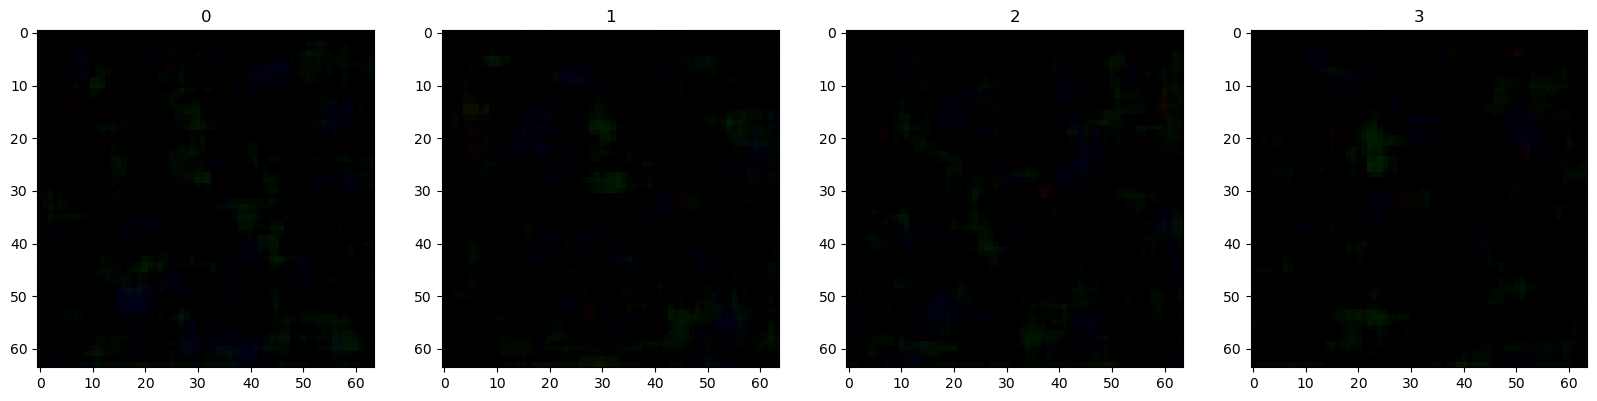

In [32]:
img = generator.predict(np.random.randn(4,128,1))
# Setup the subplot formatting 
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
# Loop four times and get images 
for idx, img in enumerate(img): 
    # Plot the image using a specific subplot 
    ax[idx].imshow(np.squeeze(img))
    # Appending the image label as the plot title 
    ax[idx].title.set_text(idx)

In [33]:
def build_discriminator(): 
    model = Sequential()
    
    # Adjust input shape (e.g., 64x64x3 for color images)
    model.add(Conv2D(64, kernel_size=5, strides=2, padding='same', input_shape=(64, 64, 3)))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.4))
    
    model.add(Conv2D(128, kernel_size=5, strides=2, padding='same'))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.4))
    
    model.add(Conv2D(256, kernel_size=5, strides=2, padding='same'))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.4))
    
    model.add(Conv2D(512, kernel_size=5, strides=2, padding='same'))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.4))
    
    model.add(Flatten())
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))
    
    return model 


In [34]:
discriminator = build_discriminator()

In [35]:
discriminator.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 4, 4, 512)      │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         8,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,314,753 (16.46 MB)

 Trainable params: 4,314,753 (16.46 MB)

 Non-trainable params: 0 (0.00 B)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


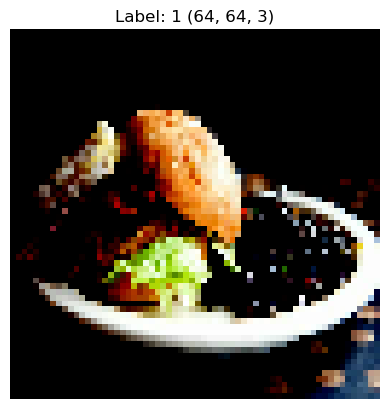

In [36]:
# Tomar un batch del dataset (devuelve un objeto iterable)
sample = next(iter(tf_dataset.take(1)))  # Extrae un batch

# Si los datos están en formato (imagen, etiqueta), extraer solo la imagen
image, label = sample

# Si el batch tiene más de una imagen, seleccionar la primera
image = image[1].numpy()
label = label[1].numpy()

# Mostrar la imagen
plt.imshow(image)
plt.title(f"Label: {label} {image.shape}")
plt.axis("off")
plt.show()

In [37]:
# Adam is going to be the optimizer for both
from tensorflow.keras.optimizers import Adam
# Binary cross entropy is going to be the loss for both 
from tensorflow.keras.losses import BinaryCrossentropy

In [51]:
g_opt = Adam(learning_rate=0.0001) 
d_opt = Adam(learning_rate=0.00001) 
g_loss = BinaryCrossentropy()
d_loss = BinaryCrossentropy()

In [52]:
# Importing the base model class to subclass our training step 
from tensorflow.keras.models import Model

In [65]:
class DCGAN(Model): 
    def __init__(self, generator, discriminator, *args, **kwargs):
        # Pass through args and kwargs to base class 
        super().__init__(*args, **kwargs)
        
        # Create attributes for gen and disc
        self.generator = generator 
        self.discriminator = discriminator 
        
    def compile(self, g_opt, d_opt, g_loss, d_loss, *args, **kwargs): 
        # Compile with base class
        super().compile(*args, **kwargs)
        
        # Create attributes for losses and optimizers
        self.g_opt = g_opt
        self.d_opt = d_opt
        self.g_loss = g_loss
        self.d_loss = d_loss 

    def train_step(self, batch):
        batch, _ = batch  # Unpack images and labels
        batch_size = tf.shape(batch)[0]  # Get batch size as tensor
        batch_size = tf.cast(batch_size, tf.int32)  # Ensure int32
        batch_size_f = tf.cast(batch_size, tf.float32)  # Convert to float32 if needed
    
        # Get the data 
        real_images = tf.cast(batch, tf.float32)  # Ensure input images are float32
        random_latent_vectors = tf.random.normal((batch_size, 128))  # Generate noise
    
        # Generate Fake Images
        fake_images = self.generator(random_latent_vectors, training=True)
    
        # Train the discriminator
        with tf.GradientTape() as d_tape: 
            yhat_real = self.discriminator(real_images, training=True) 
            yhat_fake = self.discriminator(fake_images, training=True)
            
            # Etiquetas reales suavizadas con ruido
            real_labels = tf.ones_like(yhat_real) * 0.9 + 0.1 * tf.random.uniform(tf.shape(yhat_real))
            fake_labels = tf.zeros_like(yhat_fake) + 0.1 * tf.random.uniform(tf.shape(yhat_fake))
            
            # Concatenar predicciones y etiquetas
            yhat_realfake = tf.concat([yhat_real, yhat_fake], axis=0)
            y_realfake = tf.concat([real_labels, fake_labels], axis=0)
            
            # Calcular pérdida
            total_d_loss = self.d_loss(y_realfake, yhat_realfake)

    
        dgrad = d_tape.gradient(total_d_loss, self.discriminator.trainable_variables) 
        self.d_opt.apply_gradients(zip(dgrad, self.discriminator.trainable_variables))
    
        # Train the generator
        with tf.GradientTape() as g_tape: 
            gen_images = self.generator(tf.random.normal((batch_size, 128)), training=True)
            predicted_labels = self.discriminator(gen_images, training=False)
            
            total_g_loss = self.g_loss(tf.ones_like(predicted_labels), predicted_labels)  # Trick discriminator
        
        ggrad = g_tape.gradient(total_g_loss, self.generator.trainable_variables)
        self.g_opt.apply_gradients(zip(ggrad, self.generator.trainable_variables))
        
        return {"d_loss": total_d_loss, "g_loss": total_g_loss}



In [66]:
# Create instance of subclassed model
dcgan = DCGAN(generator, discriminator)

In [67]:
# Compile the model
dcgan.compile(g_opt, d_opt, g_loss, d_loss)

In [68]:
import os
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.callbacks import Callback

In [69]:
class ModelMonitor(Callback):
    def __init__(self, num_img=3, latent_dim=128):
        self.num_img = num_img
        self.latent_dim = latent_dim

    def on_epoch_end(self, epoch, logs=None):
        random_latent_vectors = tf.random.normal((self.num_img, self.latent_dim))
        generated_images = self.model.generator(random_latent_vectors)
        generated_images = (generated_images * 127.5) + 127.5  # Scale back to [0,255]
        generated_images = tf.cast(generated_images, tf.uint8)

        for i in range(self.num_img):
            img = array_to_img(generated_images[i])
            img.save(os.path.join('images', f'generated_img_{epoch}_{i}.png'))


In [70]:
hist = dcgan.fit(tf_dataset, epochs=3, callbacks=[ModelMonitor()])

Epoch 1/3


2025-03-21 22:26:30.763384: W tensorflow/compiler/tf2xla/kernels/random_ops.cc:62] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. random_uniform/RandomUniform


  27/2698 ━━━━━━━━━━━━━━━━━━━━ 2:33 57ms/step - d_loss: 0.6311 - g_loss: 6.7215   

2025-03-21 22:26:42.168658: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile


  86/2698 ━━━━━━━━━━━━━━━━━━━━ 2:04 47ms/step - d_loss: 0.5627 - g_loss: 4.7636

...

2316/2698 ━━━━━━━━━━━━━━━━━━━━ 30s 79ms/step - d_loss: 0.2006 - g_loss: 2.7374

2025-03-21 22:35:23.739380: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile


2319/2698 ━━━━━━━━━━━━━━━━━━━━ 29s 79ms/step - d_loss: 0.2006 - g_loss: 2.7376

2025-03-21 22:35:24.035476: W tensorflow/core/lib/png/png_io.cc:92] PNG warning: iCCP: known incorrect sRGB profile


2698/2698 ━━━━━━━━━━━━━━━━━━━━ 222s 82ms/step - d_loss: 0.2005 - g_loss: 2.7444


In [59]:
for batch, labels in tf_dataset.take(1):
    print("Batch Shape:", batch.shape)


Batch Shape: (32, 64, 64, 3)


2025-03-21 22:16:42.540348: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [71]:
for batch in tf_dataset[0].take(1):
    print("Batch Shape:", batch.shape)
    print("Batch dtype:", batch.dtype)


TypeError: '_PrefetchDataset' object is not subscriptable

In [72]:
dcgan.save("generator_model.h5")
dcgan.save("generator_model.keras")

In [73]:
dcgan.load_weights("generator_model.h5")


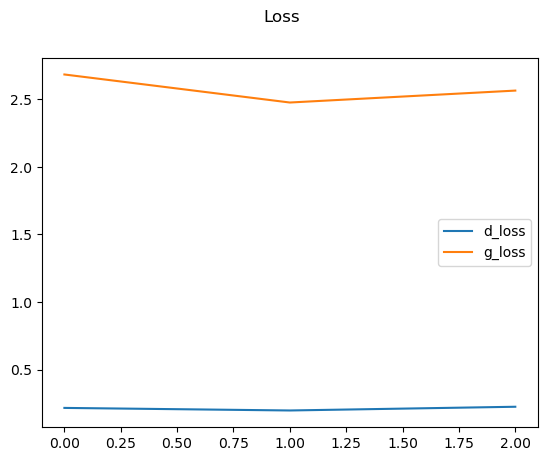

In [74]:
plt.suptitle('Loss')
plt.plot(hist.history['d_loss'], label='d_loss')
plt.plot(hist.history['g_loss'], label='g_loss')
plt.legend()
plt.show()


In [75]:
imgs = generator.predict(tf.random.normal((16, 128, 1)))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


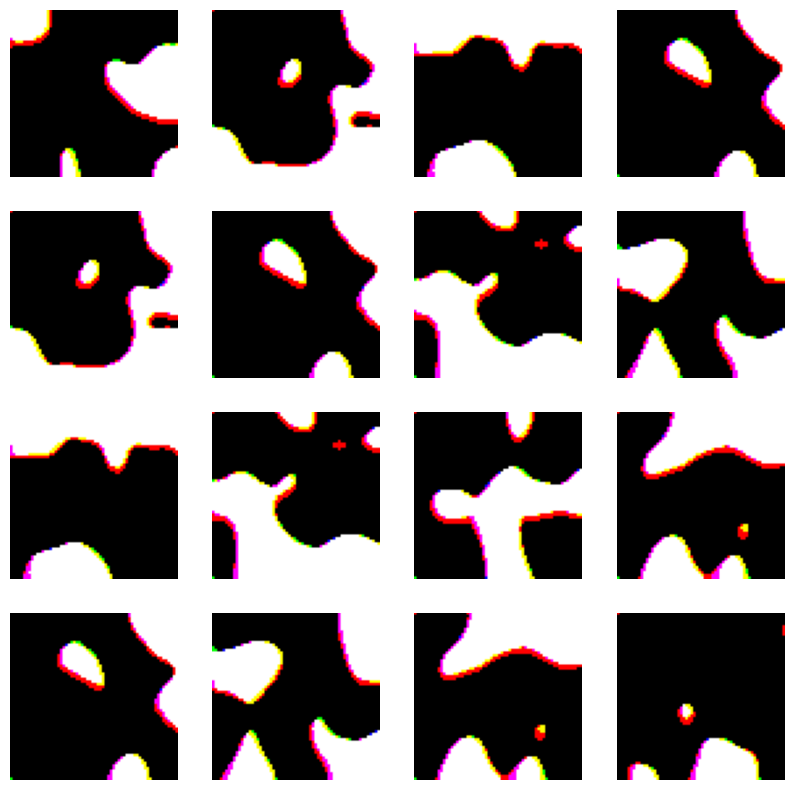

In [76]:
fig, ax = plt.subplots(ncols=4, nrows=4, figsize=(10, 10))

# Normalize images to [0,1]
imgs = (imgs + 1) / 2 

for r in range(4):
    for c in range(4):
        ax[r, c].imshow(imgs[(r + 1) * (c + 1) - 1])
        ax[r, c].axis('off')  # Hide axes for better visualization

plt.show()



In [ ]:
ideas: limitar la base de datos que le paso a tf, aumentar el image size y eso modifica el modelo..

# Generate real and fake images

# Compute inception score

# Compute Frechnet Inception Distance

Inspired on this :https://github.com/nicknochnack/GANBasics/blob/main/FashionGAN-Tutorial.ipynb and https://www.youtube.com/watch?v=AALBGpLbj6Q&ab_channel=NicholasRenotte